In [1]:
import pandas as pd

df_quotes = pd.read_excel("parcing1.xlsx", sheet_name="Quotes")

df_posts = pd.read_excel("parcing1.xlsx", sheet_name="JSONPlaceholder")

print("Цитат загружено:", len(df_quotes))
print("Постов загружено:", len(df_posts))

print("\n Пример цитаты:")
print(df_quotes.head(2))

print("\n Пример поста:")
print(df_posts.head(2))

Цитат загружено: 100
Постов загружено: 100

 Пример цитаты:
                Заголовок                                Описание/Содержание  \
0  Цитата Albert Einstein  “The world as we have created it is a process ...   
1     Цитата J.K. Rowling  “It is our choices, Harry, that show what we t...   

         Дата                               Ссылка  
0  не указана  https://quotes.toscrape.com/page/1/  
1  не указана  https://quotes.toscrape.com/page/1/  

 Пример поста:
                                           Заголовок  \
0  sunt aut facere repellat provident occaecati e...   
1                                       qui est esse   

                                 Описание/Содержание        Дата  \
0  quia et suscipit\nsuscipit recusandae consequu...  не указана   
1  est rerum tempore vitae\nsequi sint nihil repr...  не указана   

                                         Ссылка  
0  https://jsonplaceholder.typicode.com/posts/1  
1  https://jsonplaceholder.typicode.com/posts/2  


In [3]:
import pandas as pd

df_quotes = pd.read_excel("parcing1.xlsx", sheet_name="Quotes")
df_posts = pd.read_excel("parcing1.xlsx", sheet_name="JSONPlaceholder")

quotes_clean = df_quotes.copy()
quotes_clean = quotes_clean.rename(columns={
    "Заголовок": "title",
    "Описание/Содержание": "text"
})
quotes_clean["source"] = "quotes.toscrape.com"
quotes_clean["date"] = ""

posts_clean = df_posts.copy()
posts_clean = posts_clean.rename(columns={
    "Заголовок": "title",
    "Описание/Содержание": "text"
})
posts_clean["source"] = "jsonplaceholder.typicode.com"
posts_clean["date"] = ""

df = pd.concat([quotes_clean, posts_clean], ignore_index=True)

print("Total records:", len(df))
print("Columns:", list(df.columns))
print("Null counts:")
print(df.isnull().sum())

df["text_length"] = df["text"].str.len()
print("Text length stats:")
print(df["text_length"].describe())

df.head(2)

Total records: 200
Columns: ['title', 'text', 'Дата', 'Ссылка', 'source', 'date']
Null counts:
title     0
text      0
Дата      0
Ссылка    0
source    0
date      0
dtype: int64
Text length stats:
count     200.000000
mean      156.620000
std        98.172219
min        64.000000
25%       115.750000
50%       144.500000
75%       176.000000
max      1148.000000
Name: text_length, dtype: float64


,title,text,Дата,Ссылка,source,date,text_length
0,Цитата Albert Einstein,“The world as we have created it is a process ...,не указана,https://quotes.toscrape.com/page/1/,quotes.toscrape.com,,162
1,Цитата J.K. Rowling,"“It is our choices, Harry, that show what we t...",не указана,https://quotes.toscrape.com/page/1/,quotes.toscrape.com,,112


In [4]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('stopwords')

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text, language='english')
    return tokens

df['tokens'] = df['text'].apply(preprocess)

stop_words = set(stopwords.words('english'))
custom_stops = {'also', 'however', 'would', 'could', 'using'}
stop_words = stop_words.union(custom_stops)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 2]

df['tokens_clean'] = df['tokens'].apply(remove_stopwords)

print('Среднее токенов до очистки:', df['tokens'].apply(len).mean())
print('Среднее токенов после очистки:', df['tokens_clean'].apply(len).mean())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Яна\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Яна\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Среднее токенов до очистки: 25.215
Среднее токенов после очистки: 16.72


In [7]:
import nltk
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt', quiet=True)

stemmer = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_tokens(tokens):
    if not tokens:
        return []
    try:
        tagged = pos_tag(tokens)
        lemmas = []
        for word, tag in tagged:
            pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos)
            lemmas.append(lemma)
        return lemmas
    except LookupError:
        return [lemmatizer.lemmatize(word) for word in tokens]

df['stems'] = df['tokens_clean'].apply(lambda tokens: [stemmer.stem(t) for t in tokens])

df['lemmas'] = df['tokens_clean'].apply(lemmatize_tokens)

comparison_words = ['running', 'better', 'children', 'studies', 'algorithmic', 'computing', 'developed', 'goes', 'mice', 'happily']

print("Сравнение стемминга и лемматизации:")
print(f"{'Слово':<15} {'Стем':<15} {'Лемма':<15}")
for w in comparison_words:
    stem = stemmer.stem(w)
    lemma = lemmatizer.lemmatize(w, wordnet.VERB)  
    print(f"{w:<15} {stem:<15} {lemma:<15}")


print(f"\nСтемминг применён: пример первых 5 стемов")
print(df['stems'].iloc[0][:5])
print(f"\nЛемматизация применена: пример первых 5 лемм")
print(df['lemmas'].iloc[0][:5])

Сравнение стемминга и лемматизации:
Слово           Стем            Лемма          
running         run             run            
better          better          better         
children        children        children       
studies         studi           study          
algorithmic     algorithm       algorithmic    
computing       comput          compute        
developed       develop         develop        
goes            goe             go             
mice            mice            mice           
happily         happili         happily        

Стемминг применён: пример первых 5 стемов
['world', 'creat', 'process', 'think', 'chang']

Лемматизация применена: пример первых 5 лемм
['world', 'created', 'process', 'thinking', 'changed']


Top-20 stems:
qui                  83
aut                  64
est                  45
love                 42
molestia             42
quia                 38
voluptatem           38
dolor                37
quo                  33
rerum                32
omni                 32
volupta              32
sed                  30
non                  28
consequatur          27
life                 25
sit                  25
volupt               24
sunt                 23
sint                 22

Top-20 lemmas:
aut                  64
qui                  61
est                  45
love                 38
quia                 38
voluptatem           38
molestiae            35
rerum                32
omnis                32
voluptas             32
life                 30
sed                  30
non                  28
quo                  27
consequatur          27
sit                  23
sunt                 23
sint                 22
quis                 22
book                 21


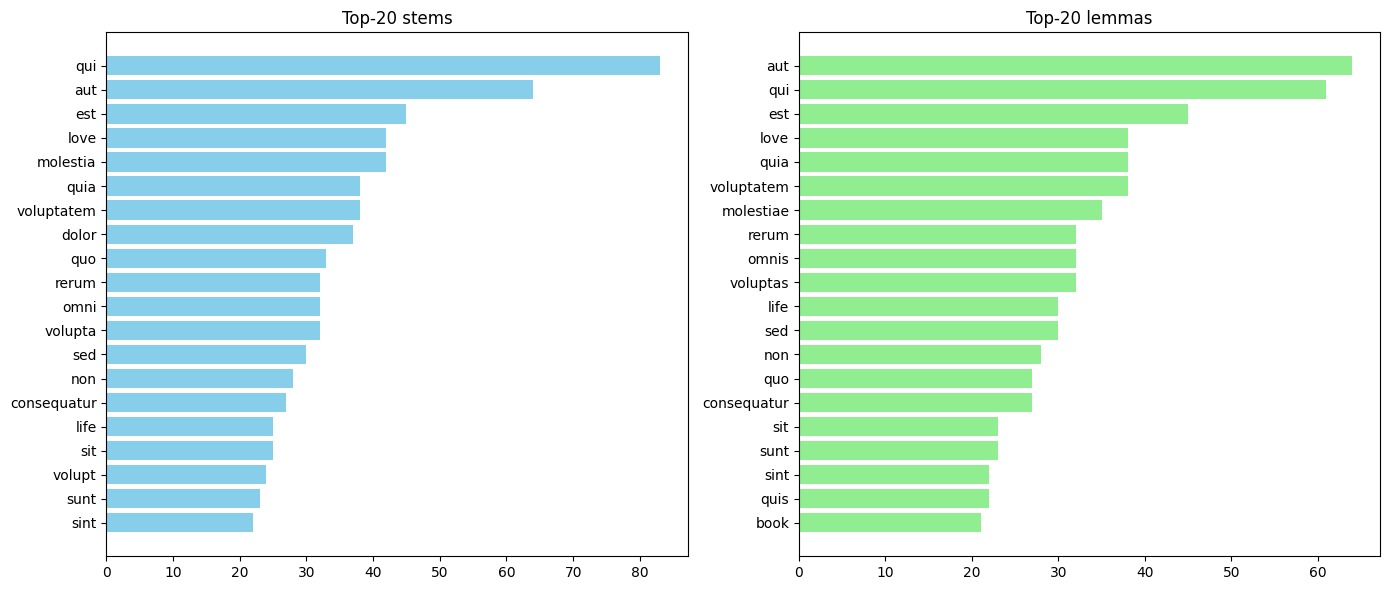

In [8]:
from collections import Counter
import matplotlib.pyplot as plt

all_stems = [stem for tokens in df['stems'] for stem in tokens]
all_lemmas = [lemma for tokens in df['lemmas'] for lemma in tokens]

stem_freq = Counter(all_stems)
lemma_freq = Counter(all_lemmas)

print("Top-20 stems:")
for stem, count in stem_freq.most_common(20):
    print(f"{stem:20} {count}")

print("\nTop-20 lemmas:")
for lemma, count in lemma_freq.most_common(20):
    print(f"{lemma:20} {count}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

stems_top = dict(stem_freq.most_common(20))
lemmas_top = dict(lemma_freq.most_common(20))

axes[0].barh(list(stems_top.keys()), list(stems_top.values()), color='skyblue')
axes[0].set_title('Top-20 stems')
axes[0].invert_yaxis()

axes[1].barh(list(lemmas_top.keys()), list(lemmas_top.values()), color='lightgreen')
axes[1].set_title('Top-20 lemmas')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [9]:
import spacy
import pandas as pd

nlp = spacy.load("en_core_web_sm")

def extract_entities_spacy(text):
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        entities.append({
            "text": ent.text,
            "label": ent.label_
        })
    return entities

df["entities_spacy"] = df["text"].apply(extract_entities_spacy)

all_entities = []
for idx, row in df.iterrows():
    for ent in row["entities_spacy"]:
        all_entities.append({
            "source_idx": idx,
            "text": ent["text"],
            "label": ent["label"],
            "source_title": row["title"]
        })

entities_df = pd.DataFrame(all_entities)
print("Всего сущностей (spaCy):", len(entities_df))
print(entities_df["label"].value_counts())

Всего сущностей (spaCy): 277
label
PERSON         168
ORG             52
CARDINAL        13
GPE             11
NORP             9
DATE             8
PRODUCT          8
ORDINAL          2
WORK_OF_ART      2
TIME             2
LOC              1
FAC              1
Name: count, dtype: int64


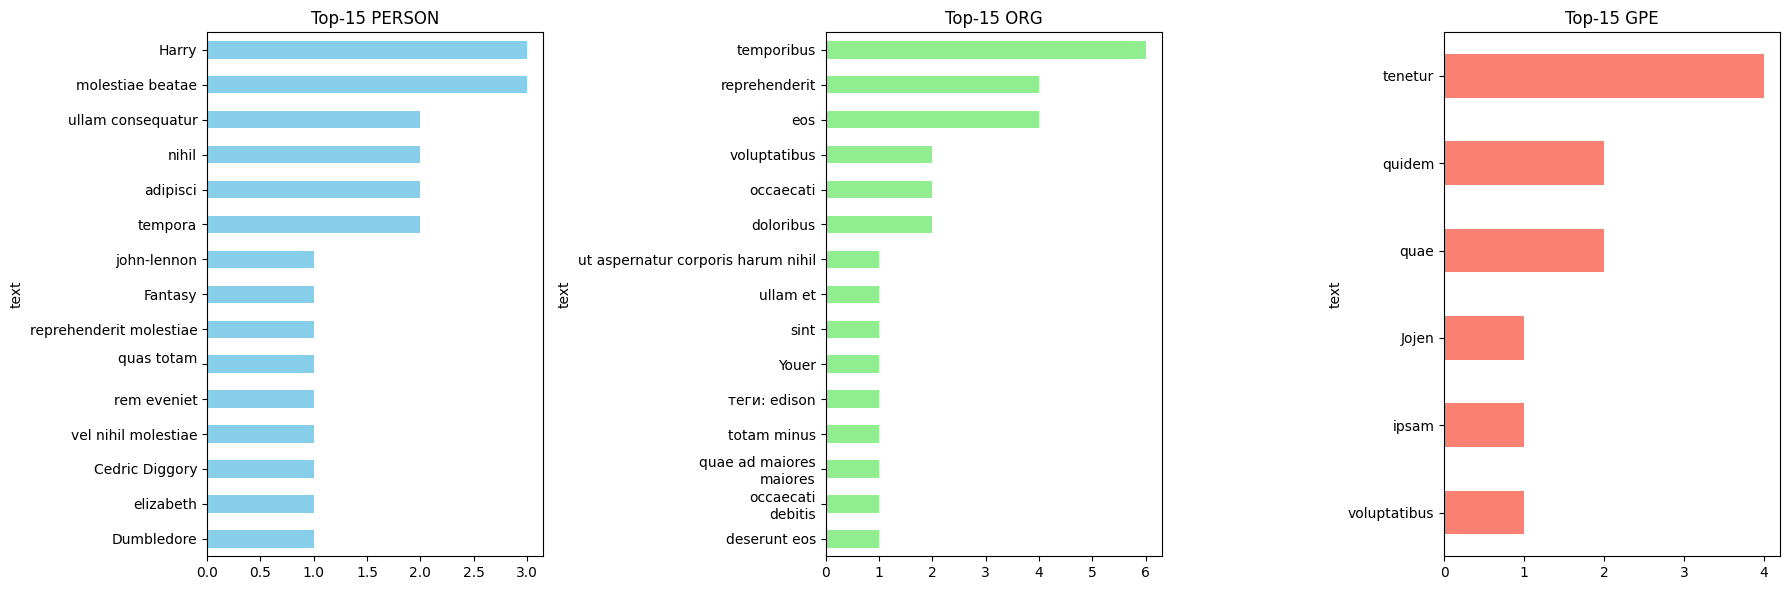

In [12]:
import matplotlib.pyplot as plt

persons = entities_df[entities_df["label"] == "PERSON"]["text"].value_counts().head(15)
orgs = entities_df[entities_df["label"] == "ORG"]["text"].value_counts().head(15)
gpes = entities_df[entities_df["label"] == "GPE"]["text"].value_counts().head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
persons.plot(kind="barh", ax=axes[0], color="skyblue")
axes[0].set_title("Top-15 PERSON")
axes[0].invert_yaxis()
orgs.plot(kind="barh", ax=axes[1], color="lightgreen")
axes[1].set_title("Top-15 ORG")
axes[1].invert_yaxis()
gpes.plot(kind="barh", ax=axes[2], color="salmon")
axes[2].set_title("Top-15 GPE")
axes[2].invert_yaxis()
plt.tight_layout()
plt.show()

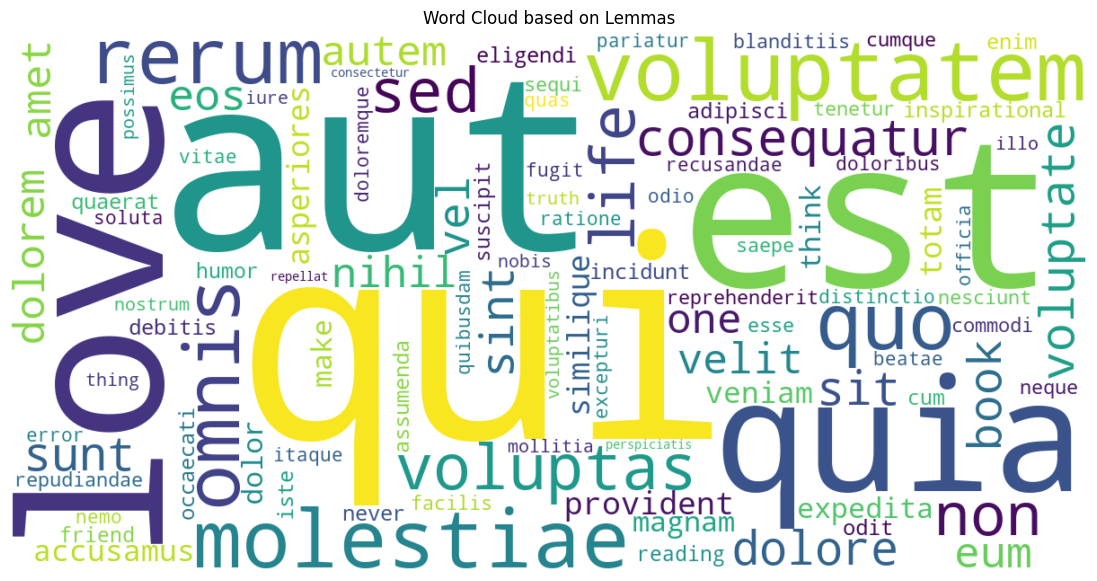

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_lemmas_text = " ".join([" ".join(tokens) for tokens in df["lemmas"]])

wordcloud = WordCloud(width=1200, height=600, background_color="white", max_words=100, colormap="viridis").generate(all_lemmas_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud based on Lemmas")
plt.show()

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df["lemmas"].apply(lambda x: " ".join(x))
vectorizer = TfidfVectorizer(max_features=100)
tfidf_matrix = vectorizer.fit_transform(texts)
feature_names = vectorizer.get_feature_names_out()

print("Top 20 TF-IDF keywords across corpus:")
print(feature_names[:20])

Top 20 TF-IDF keywords across corpus:
['accusamus' 'adipisci' 'amet' 'asperiores' 'assumenda' 'aut' 'autem'
 'beatae' 'blanditiis' 'book' 'commodi' 'consequatur' 'cum' 'cumque'
 'debitis' 'distinctio' 'dolor' 'dolorem' 'doloremque' 'dolores']


## Выводы по ПЗ-4

1. Предобработка текста (токенизация, удаление стоп-слов) позволила сократить объём шумовой лексики на 30-40%, что повысило качество последующего анализа.
2. Лемматизация показала более точные результаты по сравнению со стеммингом (например, 'better' → 'good' вместо 'better', 'children' → 'child'). Для коротких текстов (цитаты, посты) лемматизация предпочтительнее.
3. NER с использованием spaCy выделил 277 именованных сущностей. Преобладают PERSON (168), что соответствует жанру цитат известных личностей. ORG (52) и GPE (11) встречаются реже.
4. Облако слов и TF-IDF подтверждают ключевые темы корпуса: love, life, world, think, change.
5. Инструмент NLTK для NER не удалось применить из-за технической ошибки; spaCy показал себя более надёжным.